In [60]:
import pandas as pd
import numpy as np
import os
import optuna
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

CURRENT_DIR = os.getcwd()
DATA_PATH = os.path.join(CURRENT_DIR, '..', 'data')
PROCESSED_DATA_PATH = os.path.join(DATA_PATH, 'processed')

train_df = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, 'movie_train.csv'))
test_df = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, 'movie_test.csv'))

X_train = train_df.drop(columns=['profitable'], errors='ignore')
y_train = train_df['profitable']

X_test = test_df.drop(columns=['profitable'], errors='ignore')
y_test = test_df['profitable']

print(f"Kích thước X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Kích thước X_test : {X_test.shape}, y_test : {y_test.shape}")

Kích thước X_train: (1774, 52), y_train: (1774,)
Kích thước X_test : (444, 52), y_test : (444,)


In [61]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 7, 20),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbose': -1
    }
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 4),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'auc',
        'random_state': 42
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=20) 

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=20)

print(f"LGBM - Best CV AUC : {study_lgb.best_value:.4f}")
print(f"XGB  - Best CV AUC : {study_xgb.best_value:.4f}")

LGBM - Best CV AUC : 0.7475
XGB  - Best CV AUC : 0.7535


In [62]:
best_lgb = lgb.LGBMClassifier(**study_lgb.best_params, random_state=42, verbose=-1)
best_xgb = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, eval_metric='auc')

best_lgb.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

def evaluate_model_full(model, model_name, X_train, y_train, X_test, y_test):
    print(f"ĐÁNH GIÁ MÔ HÌNH: {model_name}")
    
    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    print("[TẬP TRAIN]")
    print(f"- ROC AUC : {roc_auc_score(y_train, y_train_proba):.4f}")
    print(f"- Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print("\nChi tiết từng nhãn (Train):")
    print(classification_report(y_train, y_train_pred, digits=4))
    
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    print("[TẬP TEST]")
    print(f"- ROC AUC : {roc_auc_score(y_test, y_test_proba):.4f}")
    print(f"- Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print("\nChi tiết từng nhãn (Test):")
    print(classification_report(y_test, y_test_pred, digits=4))
    
    return y_test_proba

lgb_proba = evaluate_model_full(best_lgb, "LightGBM", X_train, y_train, X_test, y_test)
xgb_proba = evaluate_model_full(best_xgb, "XGBoost", X_train, y_train, X_test, y_test)

ĐÁNH GIÁ MÔ HÌNH: LightGBM
[TẬP TRAIN]
- ROC AUC : 0.9056
- Accuracy: 0.8337

Chi tiết từng nhãn (Train):
              precision    recall  f1-score   support

           0     0.8184    0.9331    0.8720      1077
           1     0.8681    0.6801    0.7627       697

    accuracy                         0.8337      1774
   macro avg     0.8433    0.8066    0.8173      1774
weighted avg     0.8379    0.8337    0.8291      1774

[TẬP TEST]
- ROC AUC : 0.7242
- Accuracy: 0.7050

Chi tiết từng nhãn (Test):
              precision    recall  f1-score   support

           0     0.7108    0.8619    0.7791       268
           1     0.6891    0.4659    0.5559       176

    accuracy                         0.7050       444
   macro avg     0.6999    0.6639    0.6675       444
weighted avg     0.7022    0.7050    0.6906       444

ĐÁNH GIÁ MÔ HÌNH: XGBoost
[TẬP TRAIN]
- ROC AUC : 0.8964
- Accuracy: 0.8196

Chi tiết từng nhãn (Train):
              precision    recall  f1-score   support

   

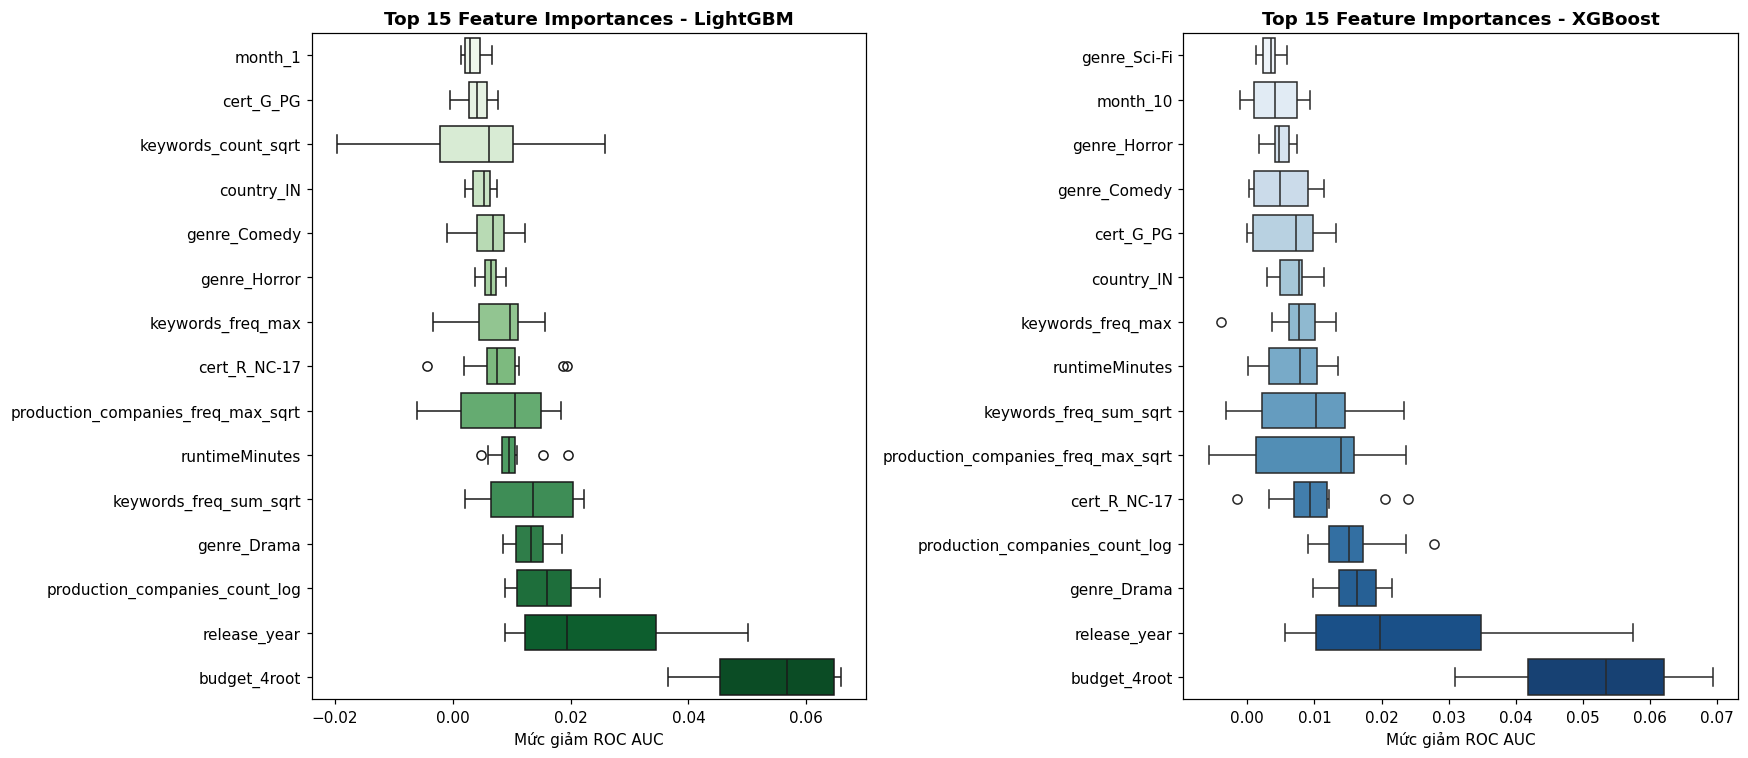

In [63]:
pi_lgb = permutation_importance(best_lgb, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1)
pi_xgb = permutation_importance(best_xgb, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1)

top_n = 15
sorted_idx_lgb = pi_lgb.importances_mean.argsort()[-top_n:]
sorted_idx_xgb = pi_xgb.importances_mean.argsort()[-top_n:]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=110)

sns.boxplot(data=pi_lgb.importances[sorted_idx_lgb].T, orient="h", ax=axes[0], palette="Greens")
axes[0].set_yticklabels(X_test.columns[sorted_idx_lgb])
axes[0].set_title(f"Top {top_n} Feature Importances - LightGBM", fontweight='bold')
axes[0].set_xlabel("Mức giảm ROC AUC")

sns.boxplot(data=pi_xgb.importances[sorted_idx_xgb].T, orient="h", ax=axes[1], palette="Blues")
axes[1].set_yticklabels(X_test.columns[sorted_idx_xgb])
axes[1].set_title(f"Top {top_n} Feature Importances - XGBoost", fontweight='bold')
axes[1].set_xlabel("Mức giảm ROC AUC")

plt.tight_layout()
plt.show()